# AIVLE스쿨 2차 미니프로젝트: 신규 아파트 주차 수요 예측

<img src = "https://github.com/Jangrae/img/blob/master/parking.png?raw=true" width=800, align="left"/>

# 단계 2: 탐색적 데이터 분석

## [미션]

단계1 에서 생성한 데이터에 대해서 탐색적 분석을 수행합니다.

1) 단변량 분석
    - 숫자형, 범주형 변수에 맞게 데이터를 탐색하며 비즈니스적 의미를 파악합니다.
2) 이변량 분석
    - 숫자형 변수 → 실차량수 상관관계를 분석합니다.    
    - 범주형 변수 → 실차량수 관계를 분석합니다.
3) 전처리(추가)
    - 범주형 변수 중에는 범줏값 개수가 적은 범주들은 유사한 범주끼리 묶어 봅니다.
    - 불필요한 변수를 제거합니다.

## 1. 환경설정

### (1) 로컬 수행(Anaconda)

- project 폴더에 필요한 파일들을 넣고, 본 파일을 열었다면, 별도 경로 지정이 필요하지 않습니다.

In [28]:
# 기본 경로
path = ''

### (4) 라이브러리 불러오기

In [31]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import scipy.stats as spst

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

In [33]:
# 표시 형식 변경
pd.set_option('display.float_format', '{:.4f}'.format)

### (5) 데이터 불러오기

- joblib.dump() 함수를 사용해 이전에 저장했던 base_data1.pkl 파일을 읽어옵니다.
- 읽어온 데이터를 apart 데이터프레임으로 선언합니다.

#### 1) 데이터 불러오기

In [69]:
# 파일 불러오기
apart = joblib.load(path+'base_data1.pkl')

In [39]:
apart.tail()

,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료
340,C0354,1485,대전충남,1993,복도식,중앙난방,전체동 설치,298,64622.2500,1479,6,0,0,6983391.8644,96514.8949
341,C1354,1386,대전충남,1993,복도식,중앙가스난방,전체동 설치,258,57616.8100,1369,17,0,0,6079848.0176,84027.5184
342,C0356,956,경기,1994,복도식,지역가스난방,전체동 설치,243,37398.7200,956,0,0,0,9931000.0000,134540.0000
343,C0358,120,강원,2020,복도식,개별가스난방,전체동 설치,47,5581.8024,120,0,0,0,2476850.0000,49271.0000
344,C0359,447,대구경북,1994,복도식,중앙유류난방,전체동 설치,78,19383.4100,447,0,0,0,7792666.6667,127053.3333


In [41]:
apart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   단지코드      345 non-null    object 
 1   총세대수      345 non-null    int64  
 2   지역        345 non-null    object 
 3   준공연도      345 non-null    int64  
 4   건물형태      345 non-null    object 
 5   난방방식      345 non-null    object 
 6   승강기설치여부   345 non-null    object 
 7   실차량수      345 non-null    int64  
 8   총면적       345 non-null    float64
 9   면적10_40   345 non-null    int64  
 10  면적40_60   345 non-null    int64  
 11  면적60_80   345 non-null    int64  
 12  면적80_200  345 non-null    int64  
 13  임대보증금     345 non-null    float64
 14  임대료       345 non-null    float64
dtypes: float64(3), int64(7), object(5)
memory usage: 40.6+ KB


## 4. 이변량 분석

- 숫자형 변수들 간의 상관관계를 분석합니다.
- 숫자형 변수 → 실차량수 상관관계를 분석합니다.    
- 볌주형 변수 → 실차량수 관계를 분석합니다.

### (1) 숫자형 변수들 간의 상관관계

- 숫자형 변수 → 실차량수 상관관계를 분석합니다.    
- 숫자형 변수들 간의 상관관계를 df.corr() 메서드와 sns.heatmap() 함수 등을 사용해 시각화 합니다.

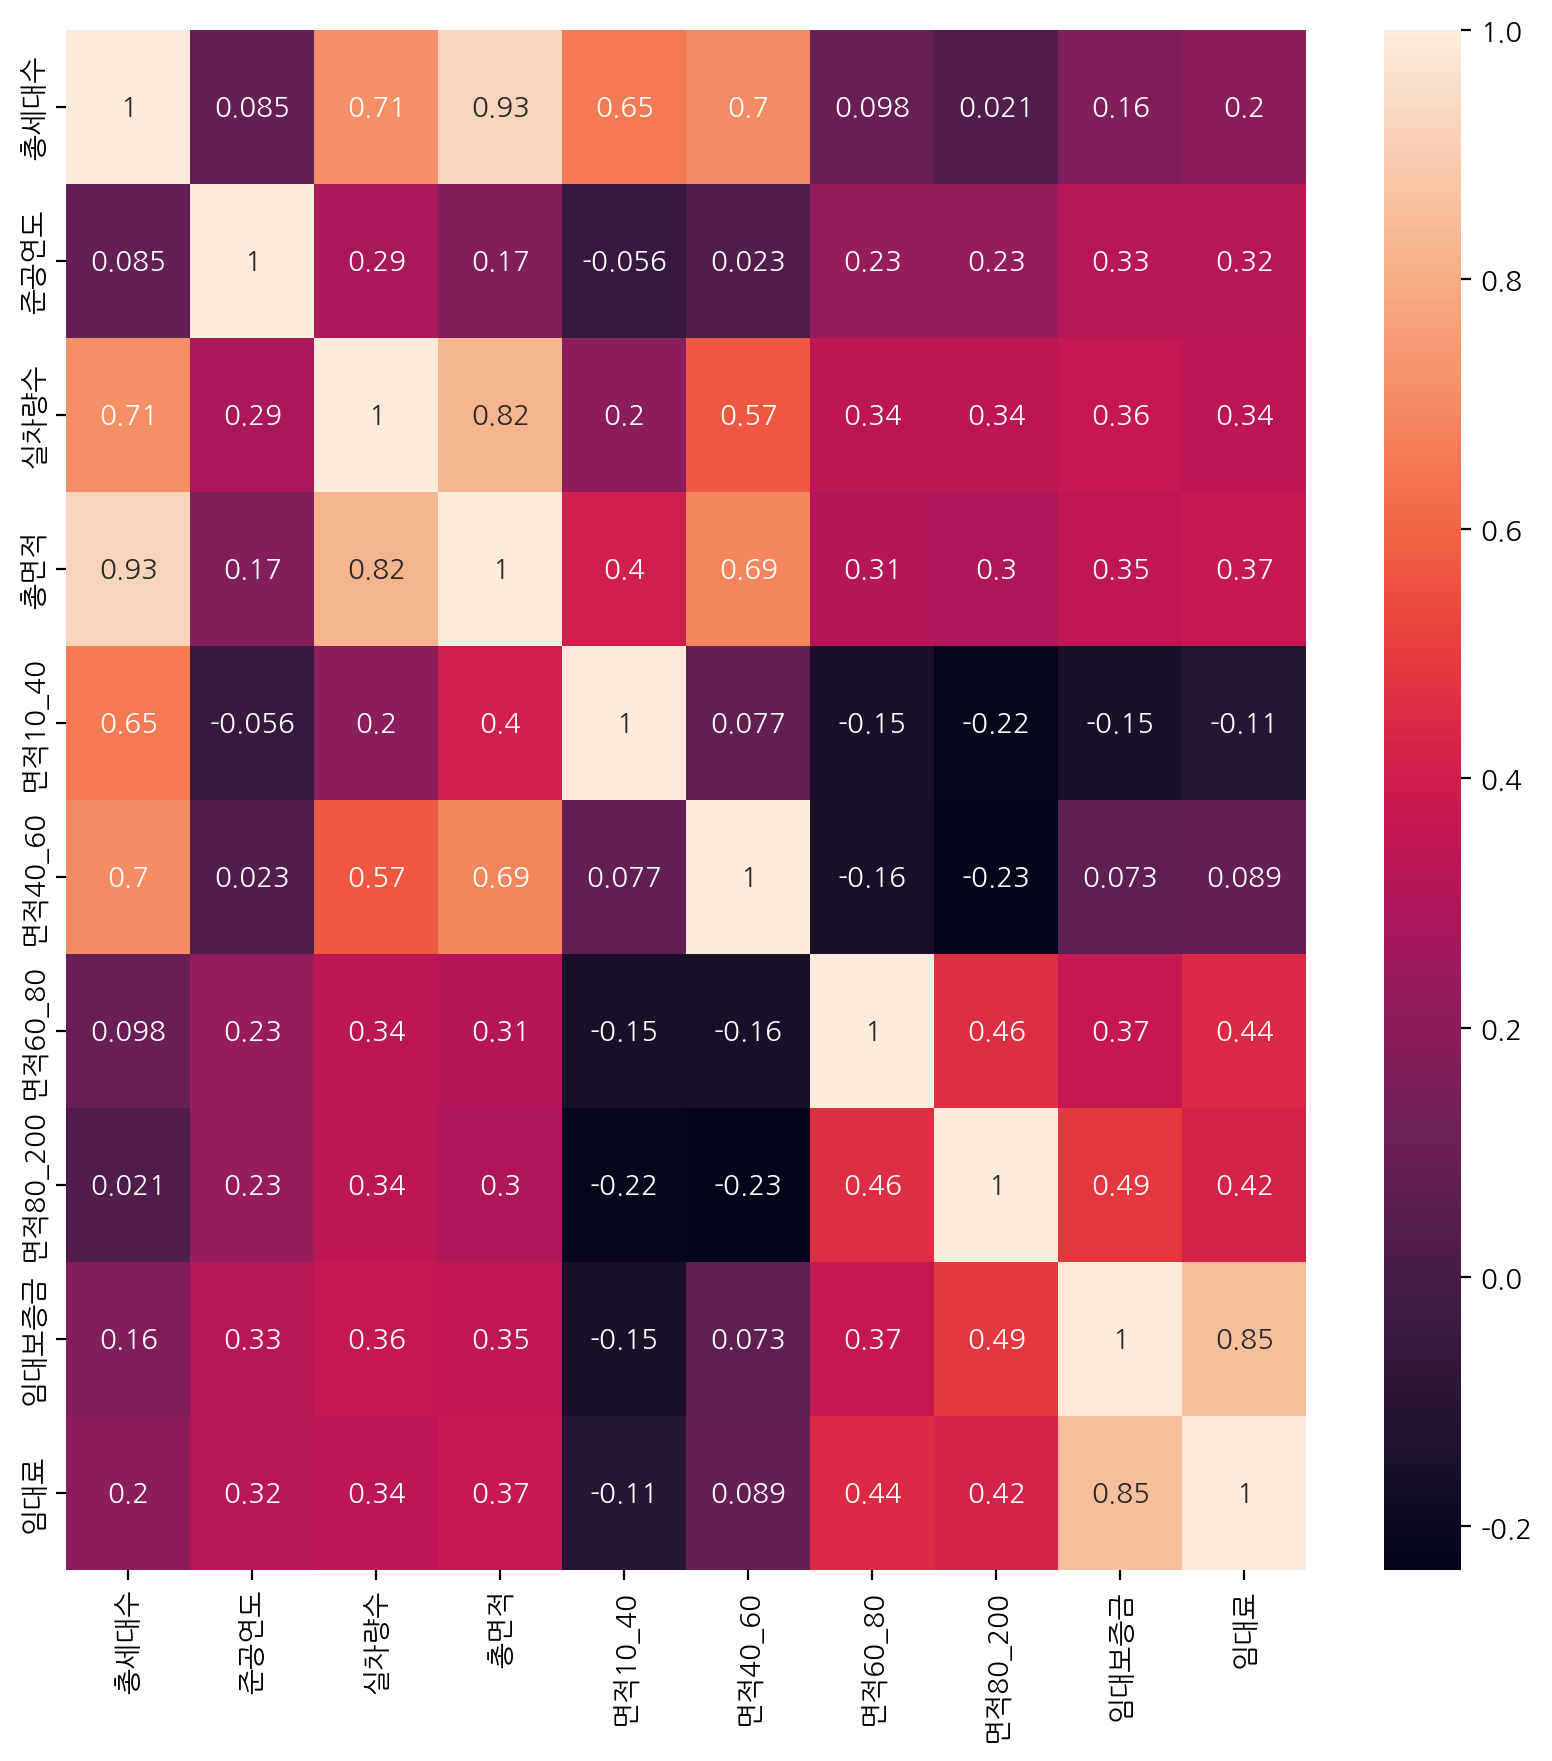

In [45]:
plt.figure(figsize=(10,10))
sns.heatmap(apart.corr(numeric_only=True),
           annot=True)
plt.show()

## 5. 추가 전처리

- '난방방식', '승강기설치여부' 두 변수에 대해서 적은 수의 범주로 묶는 작업을 진행합니다.
- '단지코드'는 개별적인 값이므로 예측과 관련이 없으니 제거합니다.
- '지역' 변수는 지역별 특성을 고려하기에는 너무 세분화 되어 있고, 특징으로 통합하기 어려우므로 제거합니다.

In [798]:
# 파일 불러오기
apart = joblib.load(path+'base_data1.pkl')

### (1) 난방방식

- '난방방식' 변수의 값을 다음과 같이 변경하여 세 개의 범줏값만 갖게 합니다.
    - 개별가스난방 → 개별
    - 개별유류난방 → 개별
    - 지역난방 → 지역
    - 지역가스난방 → 지역
    - 지역유류난방 → 지역
    - 중앙가스난방 → 중앙
    - 중앙난방 → 중앙
    - 중앙유류난방 → 중앙

In [801]:
apart.loc[apart['난방방식'].str.contains('개별'), '난방방식'] = '개별'
apart.loc[apart['난방방식'].str.contains('지역'), '난방방식'] = '지역'
apart.loc[apart['난방방식'].str.contains('중앙'), '난방방식'] = '중앙'

In [803]:
apart.head()

,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료
0,C0001,78,서울,2013,계단식,개별,전체동 설치,109,6023.7683,0,78,0,0,57598307.6923,645243.8462
1,C0002,35,서울,2013,복도식,개별,전체동 설치,35,1569.1668,35,0,0,0,63062000.0000,464533.7143
2,C0003,88,서울,2013,계단식,개별,전체동 설치,88,7180.1396,0,88,0,0,72190000.0000,586540.0000
3,C0004,477,서울,2014,복도식,지역,전체동 설치,943,47058.9273,0,150,216,111,91584727.4633,877880.2725
4,C0006,15,서울,2013,복도식,개별,전체동 설치,21,543.0268,15,0,0,0,54463150.0000,330212.0000


### (2) 승강기설치여부

- '승강기설치여부' 변수의 값을 다음과 같이 변경하여 0, 1 값을 갖게 합니다.
    - 전체동 설치 → 1
    - 일부동 설치 → 0
    - 미설치 → 0

In [806]:
apart['승강기설치여부'] = np.where(apart['승강기설치여부'] == '전체동 설치', 1, 0)

In [808]:
apart.head()

,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료
0,C0001,78,서울,2013,계단식,개별,1,109,6023.7683,0,78,0,0,57598307.6923,645243.8462
1,C0002,35,서울,2013,복도식,개별,1,35,1569.1668,35,0,0,0,63062000.0000,464533.7143
2,C0003,88,서울,2013,계단식,개별,1,88,7180.1396,0,88,0,0,72190000.0000,586540.0000
3,C0004,477,서울,2014,복도식,지역,1,943,47058.9273,0,150,216,111,91584727.4633,877880.2725
4,C0006,15,서울,2013,복도식,개별,1,21,543.0268,15,0,0,0,54463150.0000,330212.0000


### (3) 건물형태

- '건물형태' 변수의 값을 다음과 같이 변경합니다.
    - 계단식 -> 계단식
    - 복도식 -> 복도식
    - 혼합식 -> 계단식

In [811]:
apart['건물형태'] = np.where(apart['건물형태'] == '복도식', '복도식', '계단식')

In [813]:
apart.head()

,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료
0,C0001,78,서울,2013,계단식,개별,1,109,6023.7683,0,78,0,0,57598307.6923,645243.8462
1,C0002,35,서울,2013,복도식,개별,1,35,1569.1668,35,0,0,0,63062000.0000,464533.7143
2,C0003,88,서울,2013,계단식,개별,1,88,7180.1396,0,88,0,0,72190000.0000,586540.0000
3,C0004,477,서울,2014,복도식,지역,1,943,47058.9273,0,150,216,111,91584727.4633,877880.2725
4,C0006,15,서울,2013,복도식,개별,1,21,543.0268,15,0,0,0,54463150.0000,330212.0000


### (4) 준공연도

- '준공연도' 변수의 값을 다음과 같이 변경합니다.
    - 90년대
    - 00년대
    - 10년대 이후

In [816]:
apart['준공연도'] = np.where(apart['준공연도'] < 2000, '90년대', np.where(apart['준공연도'] < 2010, '00년대', '10년대 이후'))

In [818]:
apart.head()

,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료
0,C0001,78,서울,10년대 이후,계단식,개별,1,109,6023.7683,0,78,0,0,57598307.6923,645243.8462
1,C0002,35,서울,10년대 이후,복도식,개별,1,35,1569.1668,35,0,0,0,63062000.0000,464533.7143
2,C0003,88,서울,10년대 이후,계단식,개별,1,88,7180.1396,0,88,0,0,72190000.0000,586540.0000
3,C0004,477,서울,10년대 이후,복도식,지역,1,943,47058.9273,0,150,216,111,91584727.4633,877880.2725
4,C0006,15,서울,10년대 이후,복도식,개별,1,21,543.0268,15,0,0,0,54463150.0000,330212.0000


In [820]:
# 범위 고려
apart['임대료'] = pd.cut(apart['임대료'], 
                         bins=[-np.inf, 100000, 200000, 400000, np.inf], 
                         labels=['-100k', '100-200k', '200-400k', '400k-'])

In [822]:
# 범위 고려
apart['총세대수'] = pd.cut(apart['총세대수'], 
                         bins=[-np.inf, 300, 500, 1000, np.inf], 
                         labels=['-300', '300-500','500-1000','1000-'])

### (5) 단지코드, 지역 제거

- '단지코드', '지역' 변수를 제거합니다.

In [825]:
drop_cols = ['단지코드', '지역']

apart.drop(columns=drop_cols, inplace=True)

- 최종 데이터를 확인합니다.

In [828]:
apart.head()

,총세대수,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료
0,-300,10년대 이후,계단식,개별,1,109,6023.7683,0,78,0,0,57598307.6923,400k-
1,-300,10년대 이후,복도식,개별,1,35,1569.1668,35,0,0,0,63062000.0000,400k-
2,-300,10년대 이후,계단식,개별,1,88,7180.1396,0,88,0,0,72190000.0000,400k-
3,300-500,10년대 이후,복도식,지역,1,943,47058.9273,0,150,216,111,91584727.4633,400k-
4,-300,10년대 이후,복도식,개별,1,21,543.0268,15,0,0,0,54463150.0000,200-400k


## 6. 데이터 셋 저장

- joblib.dump() 함수를 사용하여 최종 데이터 셋을 파일로 저장합니다.
- 파일 이름은 base_data2.pkl로 합니다.

In [831]:
# 파일로 저장
joblib.dump(apart, path+'base_data4.pkl')

['base_data4.pkl']